# SemEval 2018 Task 1 — Multilabel Emotion Detection
## Step 1: Exploratory Data Analysis (EDA)

**Dataset structure:**  
Tab-separated files with columns: `ID`, `Tweet`, + 11 binary emotion labels  
Emotions: anger, anticipation, disgust, fear, joy, love, optimism, pessimism, sadness, surprise, trust  
Task type: **Multilabel** — a tweet can carry multiple emotion labels simultaneously

## 0. Install & Import

In [ ]:
!pip install matplotlib seaborn pandas numpy scikit-learn wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Official column order in SemEval 2018 Task 1 Subtask 5 files
EMOTIONS = [
    'anger', 'anticipation', 'disgust', 'fear',
    'joy', 'love', 'optimism', 'pessimism',
    'sadness', 'surprise', 'trust'
]
print('Ready. Emotions:', EMOTIONS)

Ready. Emotions: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']


## 1. Load Data

In [ ]:
TRAIN_PATH = '2018-E-c-En-train.txt'
DEV_PATH   = '2018-E-c-En-dev.txt'
TEST_PATH  = '2018-E-c-En-test-gold.txt'

train = pd.read_csv(TRAIN_PATH, sep='\t')
dev   = pd.read_csv(DEV_PATH,   sep='\t')
test  = pd.read_csv(TEST_PATH,  sep='\t')

print(f'Train : {len(train):,} samples, columns: {list(train.columns)}')
print(f'Dev   : {len(dev):,} samples')
print(f'Test  : {len(test):,} samples')
print(f'Total : {len(train)+len(dev)+len(test):,} samples')
train.head(3)

Train : 6,838 samples, columns: ['ID', 'Tweet', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
Dev   : 886 samples
Test  : 3,259 samples
Total : 10,983 samples


,ID,Tweet,anger,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust
0,2017-En-21441,“Worry is a down payment on a problem you may ...,0,1,0,0,0,0,1,0,0,0,1
1,2017-En-31535,Whatever you decide to do make sure it makes y...,0,0,0,0,1,1,1,0,0,0,0
2,2017-En-21068,@Max_Kellerman it also helps that the majorit...,1,0,1,0,1,0,1,0,0,0,0


## 2. Basic Statistics

In [ ]:
def basic_stats(df, name):
    lps = df[EMOTIONS].sum(axis=1)   # labels per sample
    wc  = df['Tweet'].dropna().apply(lambda x: len(x.split()))
    print(f'\n===== {name} ({len(df):,} samples) =====')
    print(f'  Missing tweets          : {df["Tweet"].isna().sum()}')
    print(f'  Duplicate tweets        : {df["Tweet"].duplicated().sum()}')
    print(f'  Samples with 0 labels   : {(lps==0).sum()} ({(lps==0).mean()*100:.1f}%)')
    print(f'  Avg labels/sample       : {lps.mean():.2f} (std={lps.std():.2f}, max={int(lps.max())})')
    print(f'  Avg tweet length (words): {wc.mean():.1f} (median={wc.median():.0f}, max={wc.max()})')

basic_stats(train, 'TRAIN')
basic_stats(dev,   'DEV')
basic_stats(test,  'TEST')


===== TRAIN (6,838 samples) =====
  Missing tweets          : 0
  Duplicate tweets        : 0
  Samples with 0 labels   : 204 (3.0%)
  Avg labels/sample       : 2.35 (std=0.99, max=6)
  Avg tweet length (words): 16.1 (median=17, max=33)

===== DEV (886 samples) =====
  Missing tweets          : 0
  Duplicate tweets        : 0
  Samples with 0 labels   : 14 (1.6%)
  Avg labels/sample       : 2.44 (std=0.97, max=6)
  Avg tweet length (words): 15.9 (median=16, max=32)

===== TEST (3,259 samples) =====
  Missing tweets          : 0
  Duplicate tweets        : 0
  Samples with 0 labels   : 75 (2.3%)
  Avg labels/sample       : 2.41 (std=0.97, max=6)
  Avg tweet length (words): 15.9 (median=16, max=36)


## 3. Label Distribution — Class Imbalance

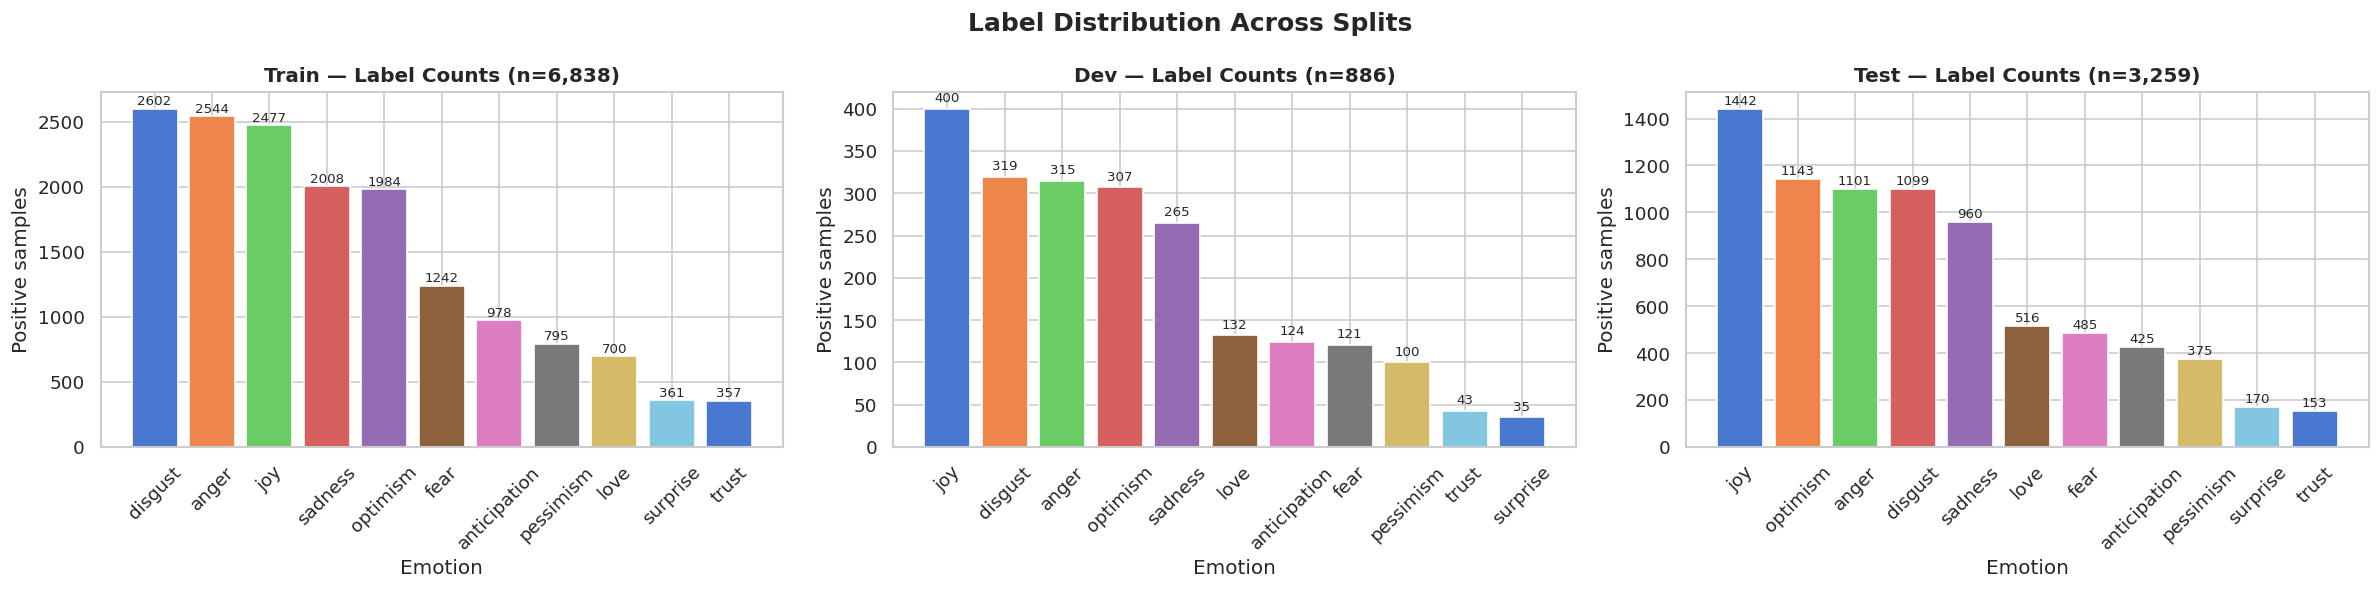

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (df, name) in zip(axes, [(train,'Train'),(dev,'Dev'),(test,'Test')]):
    counts = df[EMOTIONS].sum().sort_values(ascending=False)
    bars = ax.bar(counts.index, counts.values,
                  color=sns.color_palette('muted', len(EMOTIONS)), edgecolor='white')
    ax.set_title(f'{name} — Label Counts (n={len(df):,})', fontweight='bold')
    ax.set_xlabel('Emotion'); ax.set_ylabel('Positive samples')
    ax.tick_params(axis='x', rotation=45)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)
plt.suptitle('Label Distribution Across Splits', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('label_distribution.png', bbox_inches='tight')
plt.show()

=== Imbalance Ratio (majority class count / each class count) ===
  trust         :   7.3x
  surprise      :   7.2x
  love          :   3.7x
  pessimism     :   3.3x
  anticipation  :   2.7x
  fear          :   2.1x
  optimism      :   1.3x
  sadness       :   1.3x
  joy           :   1.1x
  anger         :   1.0x
  disgust       :   1.0x


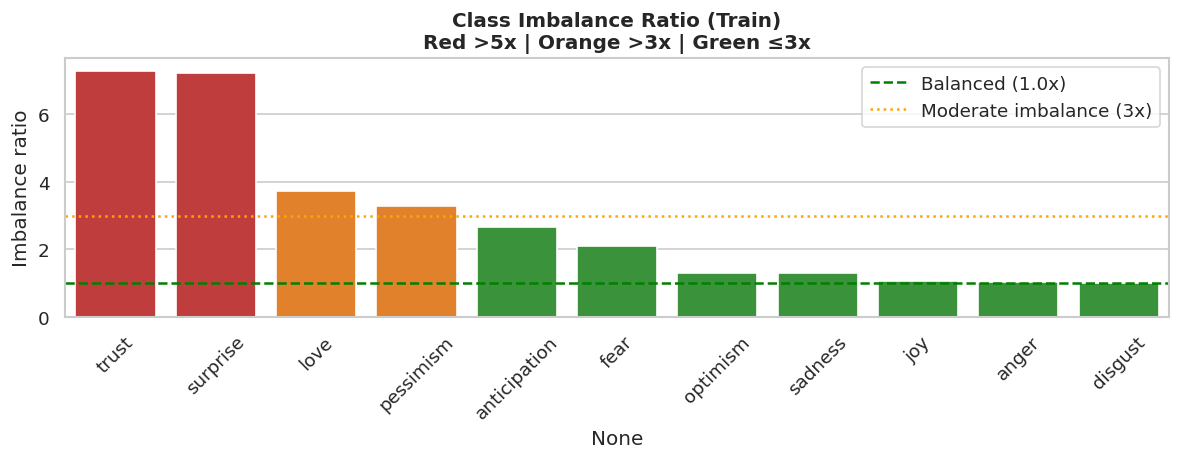

In [ ]:
# Imbalance ratio — Train set
# Expected from data: disgust(2602) is majority, trust(357) is minority → ~7.3x ratio
train_counts = train[EMOTIONS].sum().sort_values(ascending=False)
majority = train_counts.max()
ratio = (majority / train_counts).sort_values(ascending=False)

print('=== Imbalance Ratio (majority class count / each class count) ===')
for e, r in ratio.items():
    print(f'  {e:<14}: {r:5.1f}x')

plt.figure(figsize=(10, 4))
colors = ['#d62728' if r>5 else '#ff7f0e' if r>3 else '#2ca02c' for r in ratio.values]
sns.barplot(x=ratio.index, y=ratio.values, palette=colors)
plt.axhline(1.0, color='green',  linestyle='--', lw=1.5, label='Balanced (1.0x)')
plt.axhline(3.0, color='orange', linestyle=':',  lw=1.5, label='Moderate imbalance (3x)')
plt.title('Class Imbalance Ratio (Train)\nRed >5x | Orange >3x | Green ≤3x', fontweight='bold')
plt.ylabel('Imbalance ratio'); plt.xticks(rotation=45); plt.legend()
plt.tight_layout()
plt.savefig('imbalance_ratio.png', bbox_inches='tight')
plt.show()

## 4. Label Co-occurrence Heatmap

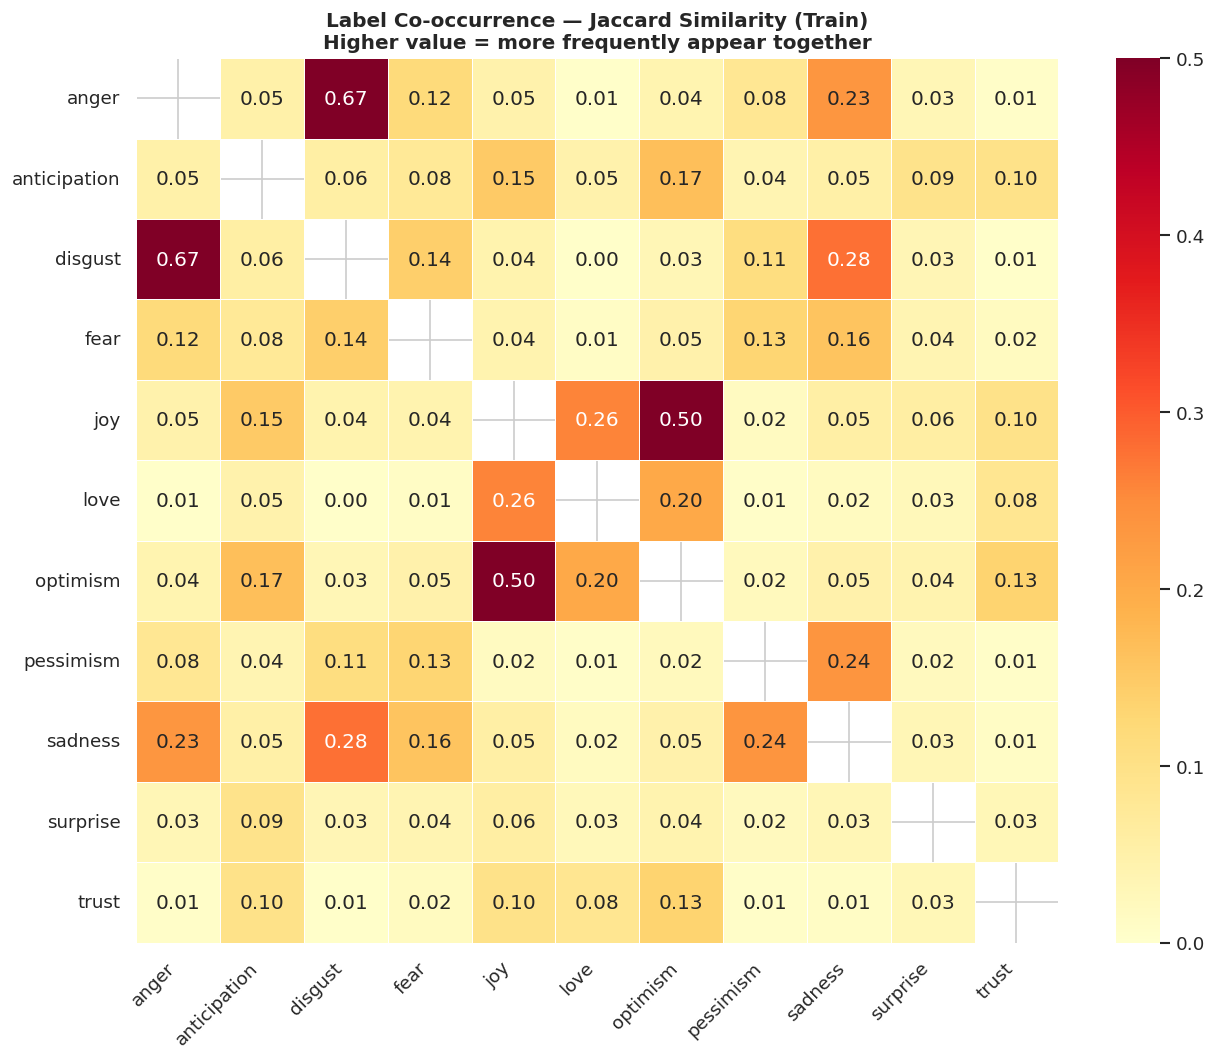

Top 5 co-occurring pairs:
  anger + disgust: 0.670
  joy + optimism: 0.504
  disgust + sadness: 0.279
  joy + love: 0.260
  pessimism + sadness: 0.237


In [ ]:
M = train[EMOTIONS].values.astype(int)
cooc = M.T @ M
diag = np.diag(cooc)
jaccard = cooc / (diag[:,None] + diag[None,:] - cooc + 1e-8)
np.fill_diagonal(jaccard, np.nan)

plt.figure(figsize=(11, 9))
sns.heatmap(jaccard, xticklabels=EMOTIONS, yticklabels=EMOTIONS,
            annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, vmin=0, vmax=0.5)
plt.title('Label Co-occurrence — Jaccard Similarity (Train)\n'
          'Higher value = more frequently appear together', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('cooccurrence_heatmap.png', bbox_inches='tight')
plt.show()

# Print top pairs
pairs = [(EMOTIONS[i], EMOTIONS[j], jaccard[i,j])
         for i in range(len(EMOTIONS)) for j in range(i+1,len(EMOTIONS))]
pairs.sort(key=lambda x: x[2], reverse=True)
print('Top 5 co-occurring pairs:')
for a,b,s in pairs[:5]: print(f'  {a} + {b}: {s:.3f}')

## 5. Labels per Sample Distribution

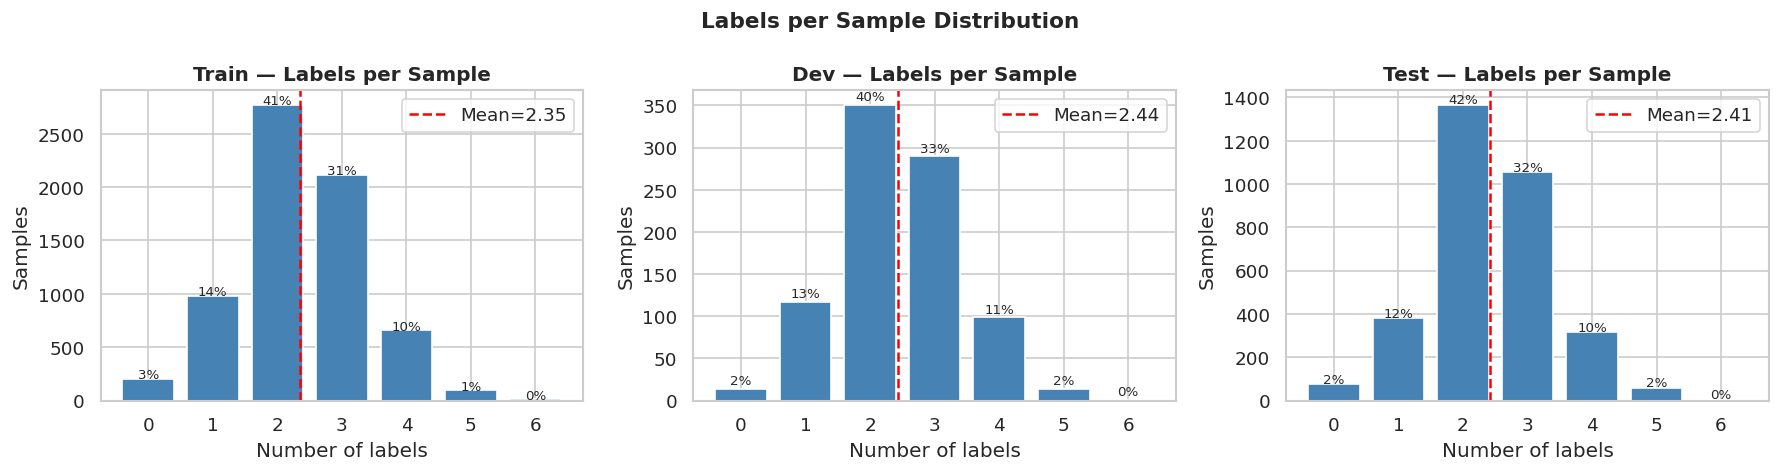

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (df, name) in zip(axes, [(train,'Train'),(dev,'Dev'),(test,'Test')]):
    lc = df[EMOTIONS].sum(axis=1)
    cd = lc.value_counts().sort_index()
    ax.bar(cd.index, cd.values, color='steelblue', edgecolor='white')
    ax.set_title(f'{name} — Labels per Sample', fontweight='bold')
    ax.set_xlabel('Number of labels'); ax.set_ylabel('Samples')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    mv = lc.mean()
    ax.axvline(mv, color='red', linestyle='--', label=f'Mean={mv:.2f}')
    ax.legend()
    for x,y in zip(cd.index, cd.values):
        ax.text(x, y+5, f'{y/len(df)*100:.0f}%', ha='center', fontsize=8)
plt.suptitle('Labels per Sample Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('labels_per_sample.png', bbox_inches='tight')
plt.show()

## 6. Tweet Length Analysis

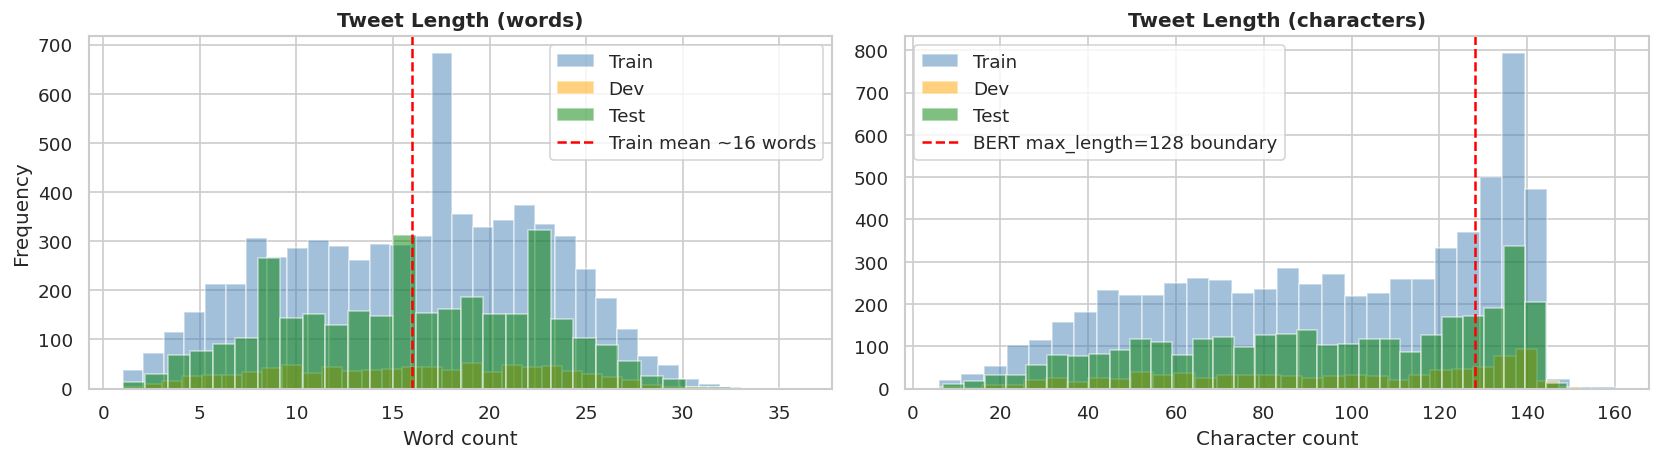

Tweets >100 words (BERT truncation risk): 0 (0.0%)
→ max_length=128 tokens is sufficient for this dataset.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for df, name, c in [(train,'Train','steelblue'),(dev,'Dev','orange'),(test,'Test','green')]:
    wc = df['Tweet'].dropna().apply(lambda x: len(x.split()))
    cc = df['Tweet'].dropna().apply(len)
    axes[0].hist(wc, bins=30, alpha=0.5, label=name, color=c)
    axes[1].hist(cc, bins=30, alpha=0.5, label=name, color=c)

axes[0].axvline(16, color='red', linestyle='--', label='Train mean ~16 words')
axes[0].set_xlabel('Word count'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Tweet Length (words)', fontweight='bold'); axes[0].legend()

axes[1].axvline(128, color='red', linestyle='--', label='BERT max_length=128 boundary')
axes[1].set_xlabel('Character count')
axes[1].set_title('Tweet Length (characters)', fontweight='bold'); axes[1].legend()

plt.tight_layout()
plt.savefig('text_length.png', bbox_inches='tight')
plt.show()

# Verify BERT max_length choice
long_tweets = (train['Tweet'].dropna().apply(lambda x: len(x.split())) > 100).sum()
print(f'Tweets >100 words (BERT truncation risk): {long_tweets} ({long_tweets/len(train)*100:.1f}%)')
print('→ max_length=128 tokens is sufficient for this dataset.')

## 7. Word Clouds per Emotion

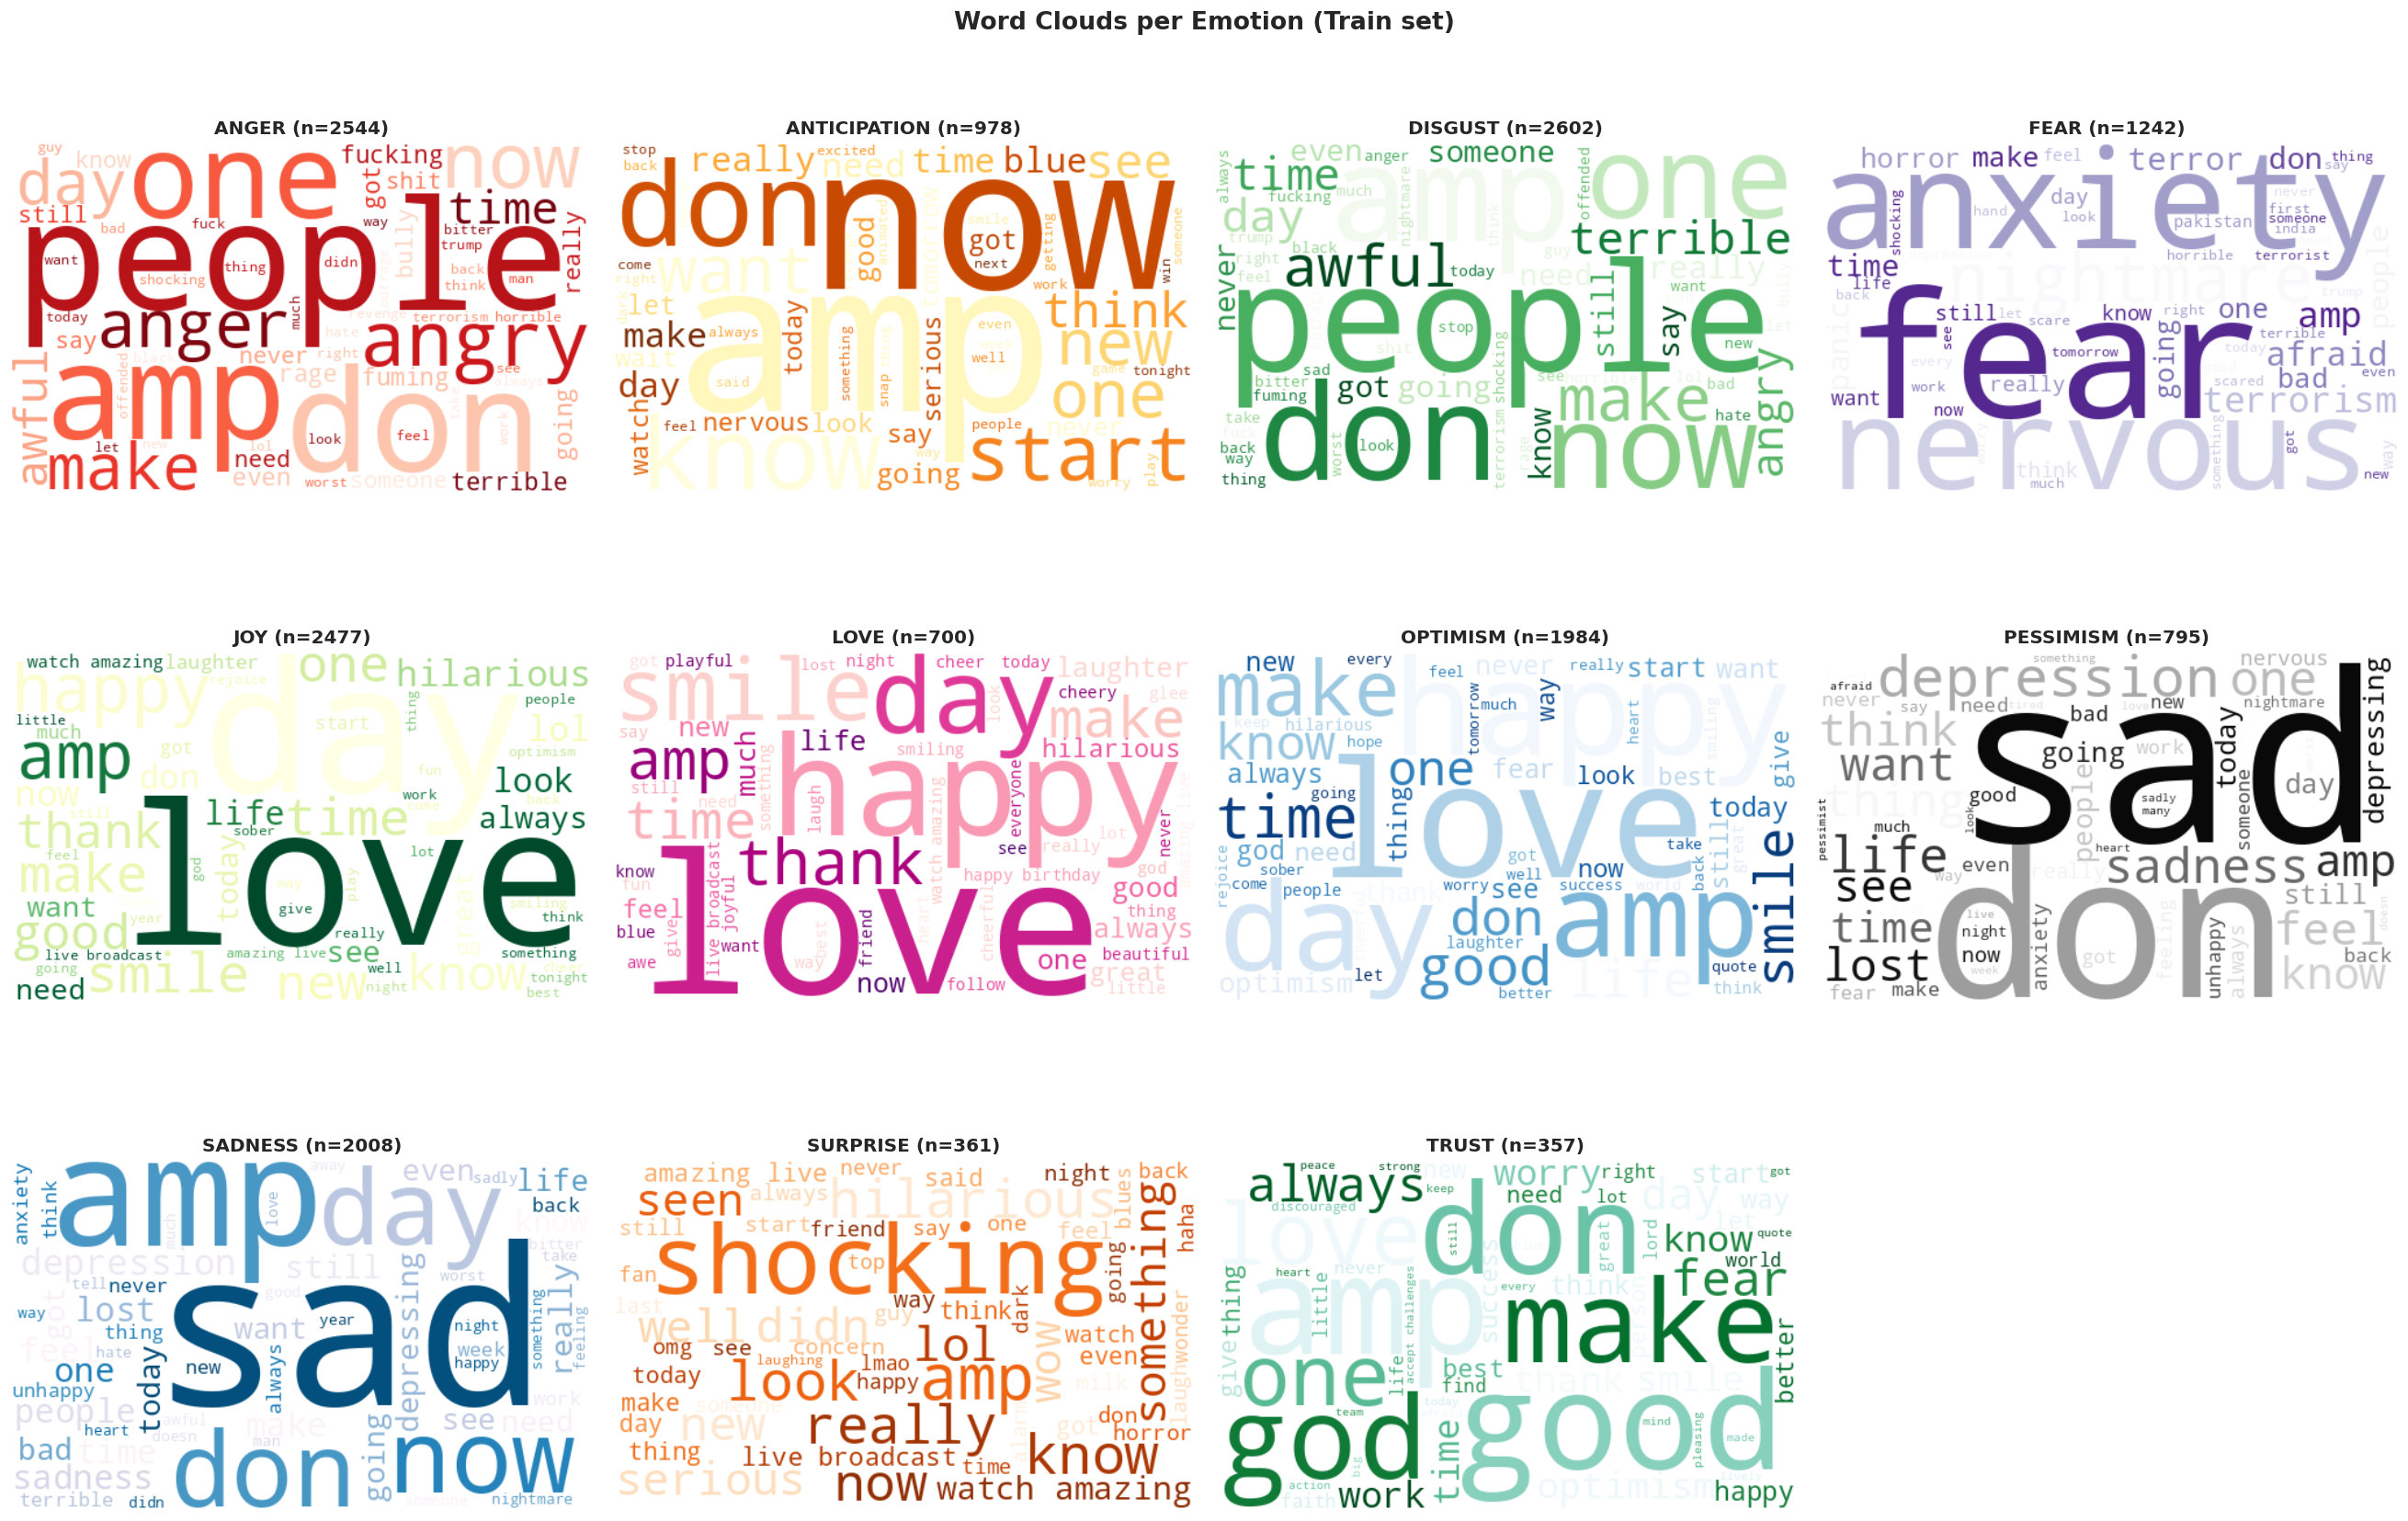

In [ ]:
STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of',
    'with','is','it','this','that','are','was','i','you','my','me',
    'we','he','she','they','be','have','do','will','not','so','as',
    'if','by','from','your','our','am','just','get','can','im','its'
}

def clean_text(text):
    t = str(text).lower()
    t = re.sub(r'http\S+|www\S+', '', t)
    t = re.sub(r'@\w+', '', t)
    t = re.sub(r'#(\w+)', r'\1', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return ' '.join(w for w in t.split() if w not in STOPWORDS and len(w) > 2)

CMAPS = {'anger':'Reds','anticipation':'YlOrBr','disgust':'Greens','fear':'Purples',
         'joy':'YlGn','love':'RdPu','optimism':'Blues','pessimism':'Greys',
         'sadness':'PuBu','surprise':'Oranges','trust':'BuGn'}

fig, axes = plt.subplots(3, 4, figsize=(22, 15))
axes = axes.flatten()
for i, emotion in enumerate(EMOTIONS):
    text = ' '.join(train[train[emotion]==1]['Tweet'].dropna().apply(clean_text))
    if len(text.strip()) < 10:
        axes[i].set_visible(False); continue
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=CMAPS[emotion], max_words=60).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{emotion.upper()} (n={int(train[emotion].sum())})',
                      fontweight='bold', fontsize=12)
    axes[i].axis('off')
for j in range(len(EMOTIONS), len(axes)): axes[j].set_visible(False)
plt.suptitle('Word Clouds per Emotion (Train set)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds.png', bbox_inches='tight')
plt.show()

## 8. Zero-label Samples — Inspect & Decide

In [ ]:
# Train has 204 samples (3%) with NO emotion label assigned
zero = train[train[EMOTIONS].sum(axis=1) == 0]
print(f'Zero-label samples in TRAIN: {len(zero)} ({len(zero)/len(train)*100:.1f}%)')
print('\nSample zero-label tweets (first 5):')
for t in zero['Tweet'].head(5): print(f'  → {str(t)[:120]}')

Zero-label samples in TRAIN: 204 (3.0%)

Sample zero-label tweets (first 5):
  → And it's hard to dance with a devil on your back\nSo shake him off.
  → @SlaveGuinevere its more of a little prick than a sting .......... but you have to come to Tennessee to get it1
  → @wabermes The @RavalliRepublic had a good one but then the reporter quit. 
  → Somewhere I rd a rpt tht Pakis wr afraid of TSD &amp; asked it 2 shut dn. Congis obliged &amp; exposed it,hounded them.t
  → @icapturpix @DRUDGE_REPORT I agree. This current, ultra-left Democratic party lost a lot of members, including myself. I


## 9. Full Summary Table

              Train_n  Train_%  Dev_n  Dev_%  Test_n  Test_%
disgust          2602     38.1    319   36.0    1099    33.7
anger            2544     37.2    315   35.6    1101    33.8
joy              2477     36.2    400   45.1    1442    44.2
sadness          2008     29.4    265   29.9     960    29.5
optimism         1984     29.0    307   34.7    1143    35.1
fear             1242     18.2    121   13.7     485    14.9
anticipation      978     14.3    124   14.0     425    13.0
pessimism         795     11.6    100   11.3     375    11.5
love              700     10.2    132   14.9     516    15.8
surprise          361      5.3     35    4.0     170     5.2
trust             357      5.2     43    4.9     153     4.7


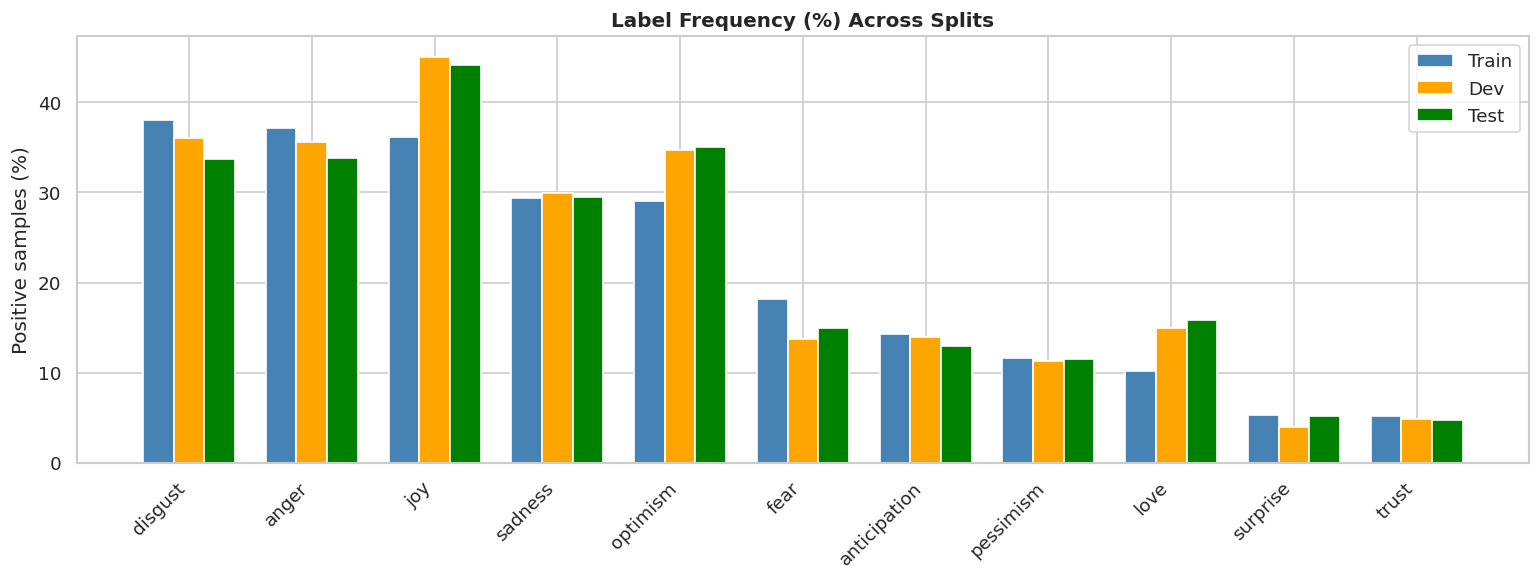

In [ ]:
summary = pd.DataFrame({
    'Train_n': train[EMOTIONS].sum(),
    'Train_%': (train[EMOTIONS].sum()/len(train)*100).round(1),
    'Dev_n':   dev[EMOTIONS].sum(),
    'Dev_%':   (dev[EMOTIONS].sum()/len(dev)*100).round(1),
    'Test_n':  test[EMOTIONS].sum(),
    'Test_%':  (test[EMOTIONS].sum()/len(test)*100).round(1),
}).sort_values('Train_n', ascending=False)

print(summary.to_string())
summary.to_csv('label_frequency_summary.csv')

# Grouped bar chart
emotions_sorted = summary.index.tolist()
x = np.arange(len(emotions_sorted)); w = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x-w, summary['Train_%'], w, label='Train', color='steelblue')
ax.bar(x,   summary['Dev_%'],   w, label='Dev',   color='orange')
ax.bar(x+w, summary['Test_%'],  w, label='Test',  color='green')
ax.set_xticks(x); ax.set_xticklabels(emotions_sorted, rotation=45, ha='right')
ax.set_ylabel('Positive samples (%)'); ax.set_title('Label Frequency (%) Across Splits', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('label_frequency_pct.png', bbox_inches='tight')
plt.show()

# SemEval 2018 Task 1 — Multilabel Emotion Detection
## Step 2: Preprocessing

### Preprocessing decisions (motivated by EDA):
| Decision | Choice | Reason |
|----------|--------|--------|
| Zero-label samples | **Keep** | Represent neutral tweets or disagreements from annotators |
| Emoji | **Convert to text** | BERT tokenizer maps emoji to [UNK]; text preserves emotion signal |
| URLs | **Remove** | No semantic content for emotion detection |
| @mentions | **Remove** | No semantic content |
| Hashtags | **Keep word, remove #** | Words carry meaning (e.g. #happy → happy) |
| Casing | **Lowercase** | Reduces vocabulary size; consistent with GloVe/BERT lowercase |
| Class imbalance | **pos_weight** | Weighted BCE loss for minority classes |

## 0. Install & Import

In [ ]:
!pip install emoji scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import re
import emoji
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

EMOTIONS = [
    'anger', 'anticipation', 'disgust', 'fear',
    'joy', 'love', 'optimism', 'pessimism',
    'sadness', 'surprise', 'trust'
]
print('Ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 3.7 MB/s eta 0:00:00
Ready.


## 1. Load Raw Data

In [ ]:
TRAIN_PATH = '2018-E-c-En-train.txt'
DEV_PATH   = '2018-E-c-En-dev.txt'
TEST_PATH  = '2018-E-c-En-test-gold.txt'

train_raw = pd.read_csv(TRAIN_PATH, sep='\t')
dev_raw   = pd.read_csv(DEV_PATH,   sep='\t')
test_raw  = pd.read_csv(TEST_PATH,  sep='\t')

print(f'Train: {len(train_raw):,} | Dev: {len(dev_raw):,} | Test: {len(test_raw):,}')
train_raw.head(3)

Train: 6,838 | Dev: 886 | Test: 3,259


,ID,Tweet,anger,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust
0,2017-En-21441,“Worry is a down payment on a problem you may ...,0,1,0,0,0,0,1,0,0,0,1
1,2017-En-31535,Whatever you decide to do make sure it makes y...,0,0,0,0,1,1,1,0,0,0,0
2,2017-En-21068,@Max_Kellerman it also helps that the majorit...,1,0,1,0,1,0,1,0,0,0,0


## 2. Text Cleaning Pipeline

In [ ]:
def clean_tweet(text: str) -> str:
    """
    Full preprocessing pipeline for a single tweet.
    Steps (in order):
      1. Convert emoji to text description
      2. Remove URLs
      3. Remove @mentions
      4. Remove # symbol but keep hashtag word
      5. Remove leftover special characters
      6. Normalize whitespace
      7. Lowercase
    """
    if not isinstance(text, str):
        return ''

    # Step 1: emoji → text  (e.g. 😢 → "crying face")
    # demojize adds colons: 😢 → :crying_face:  then we clean the colons
    text = emoji.demojize(text, delimiters=(' ', ' '))

    # Step 2: remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Step 3: remove @mentions
    text = re.sub(r'@\w+', '', text)

    # Step 4: remove # but keep the word
    text = re.sub(r'#(\w+)', r'\1', text)

    # Step 5: remove leftover special characters (keep letters, digits, spaces)
    text = re.sub(r"[^a-zA-Z0-9\s']", ' ', text)

    # Step 6: normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 7: lowercase
    text = text.lower()

    return text


# --- Sanity check on a few examples ---
examples = [
    "I'm so 😢 today... @user check this http://example.com #sad",
    "Whatever you decide to do make sure it makes you #happy. 😊",
    "This is absolutely disgusting!! 🤢🤮 #angry",
    "Worry is a down payment on a problem you may never have 💭 #motivation"
]

print('=== Cleaning Examples ===\n')
for ex in examples:
    cleaned = clean_tweet(ex)
    print(f'  BEFORE: {ex}')
    print(f'  AFTER : {cleaned}')
    print()

=== Cleaning Examples ===

  BEFORE: I'm so 😢 today... @user check this http://example.com #sad
  AFTER : i'm so crying face today check this sad

  BEFORE: Whatever you decide to do make sure it makes you #happy. 😊
  AFTER : whatever you decide to do make sure it makes you happy smiling face with smiling eyes

  BEFORE: This is absolutely disgusting!! 🤢🤮 #angry
  AFTER : this is absolutely disgusting nauseated face face vomiting angry

  BEFORE: Worry is a down payment on a problem you may never have 💭 #motivation
  AFTER : worry is a down payment on a problem you may never have thought balloon motivation



## 3. Apply Cleaning to All Splits

In [ ]:
train = train_raw.copy()
dev   = dev_raw.copy()
test  = test_raw.copy()

for df, name in [(train,'Train'), (dev,'Dev'), (test,'Test')]:
    df['clean_tweet'] = df['Tweet'].apply(clean_tweet)
    # Check for empty tweets after cleaning
    empty = (df['clean_tweet'].str.strip() == '').sum()
    print(f'{name}: {len(df):,} samples | {empty} empty after cleaning')

# Show a few before/after comparisons
print('\n=== Before vs After (Train, 5 random samples) ===')
sample = train.sample(5, random_state=42)[['Tweet', 'clean_tweet']]
for _, row in sample.iterrows():
    print(f'  BEFORE: {row["Tweet"][:100]}')
    print(f'  AFTER : {row["clean_tweet"][:100]}')
    print()

Train: 6,838 samples | 0 empty after cleaning
Dev: 886 samples | 0 empty after cleaning
Test: 3,259 samples | 0 empty after cleaning

=== Before vs After (Train, 5 random samples) ===
  BEFORE: Wishing i was rich so i didnt have to get up this morning #poor #sleepy #restless #sad #needsmoresle
  AFTER : wishing i was rich so i didnt have to get up this morning poor sleepy restless sad needsmoresleep

  BEFORE: How on earth can the projection of all that is good and happy and true in my soul be a poisonous fuc
  AFTER : how on earth can the projection of all that is good and happy and true in my soul be a poisonous fuc

  BEFORE: Don't be afraid to give up the good to go for the great. - John D. Rockefeller #quote #inspiration  
  AFTER : don't be afraid to give up the good to go for the great john d rockefeller quote inspiration great m

  BEFORE: Nice Idea collect all relevant socialmedia in one-But dont be automatic pls #worldsapp ⬅️ #chirp #ap
  AFTER : nice idea collect all relevan

## 4. Zero-label Samples — Keep & Document

In [ ]:
# Design decision: KEEP zero-label samples
# Rationale: they represent neutral/ambiguous tweets present in real-world data.

for df, name in [(train,'Train'), (dev,'Dev'), (test,'Test')]:
    zero = (df[EMOTIONS].sum(axis=1) == 0).sum()
    print(f'{name}: {zero} zero-label samples ({zero/len(df)*100:.1f}%) → KEPT')

print('\nSample zero-label tweets from train (after cleaning):')
zero_samples = train[train[EMOTIONS].sum(axis=1) == 0]['clean_tweet'].head(5)
for t in zero_samples:
    print(f'  → "{t}"')

Train: 204 zero-label samples (3.0%) → KEPT
Dev: 14 zero-label samples (1.6%) → KEPT
Test: 75 zero-label samples (2.3%) → KEPT

Sample zero-label tweets from train (after cleaning):
  → "and it's hard to dance with a devil on your back nso shake him off"
  → "its more of a little prick than a sting but you have to come to tennessee to get it1"
  → "the had a good one but then the reporter quit"
  → "somewhere i rd a rpt tht pakis wr afraid of tsd amp asked it 2 shut dn congis obliged amp exposed it hounded them time to revive badlaofuri"
  → "i agree this current ultra left democratic party lost a lot of members including myself i switched to repub"


## 5. Class Imbalance — Compute pos_weight

In [ ]:
# pos_weight for PyTorch BCEWithLogitsLoss (or equivalent in Keras)
# Formula: pos_weight[i] = (N - pos_i) / pos_i
# where N = total samples, pos_i = positive samples for class i
# This gives higher weight to minority classes during training.

N = len(train)
pos_counts = train[EMOTIONS].sum()
neg_counts = N - pos_counts
pos_weight = neg_counts / pos_counts

print(f'Training samples: {N:,}')
print(f'\n{"Emotion":<16} {"Pos":>6} {"Neg":>6} {"pos_weight":>12}')
print('-' * 44)
for emotion in EMOTIONS:
    print(f'{emotion:<16} {int(pos_counts[emotion]):>6} '
          f'{int(neg_counts[emotion]):>6} {pos_weight[emotion]:>12.2f}')

print(f'\npos_weight tensor (use this in your loss function):')
print(pos_weight.round(2).to_dict())

# Save for use in model notebooks
pos_weight_list = pos_weight.tolist()
print(f'\nAs list: {[round(w,2) for w in pos_weight_list]}')

Training samples: 6,838

Emotion             Pos    Neg   pos_weight
--------------------------------------------
anger              2544   4294         1.69
anticipation        978   5860         5.99
disgust            2602   4236         1.63
fear               1242   5596         4.51
joy                2477   4361         1.76
love                700   6138         8.77
optimism           1984   4854         2.45
pessimism           795   6043         7.60
sadness            2008   4830         2.41
surprise            361   6477        17.94
trust               357   6481        18.15

pos_weight tensor (use this in your loss function):
{'anger': 1.69, 'anticipation': 5.99, 'disgust': 1.63, 'fear': 4.51, 'joy': 1.76, 'love': 8.77, 'optimism': 2.45, 'pessimism': 7.6, 'sadness': 2.41, 'surprise': 17.94, 'trust': 18.15}

As list: [1.69, 5.99, 1.63, 4.51, 1.76, 8.77, 2.45, 7.6, 2.41, 17.94, 18.15]


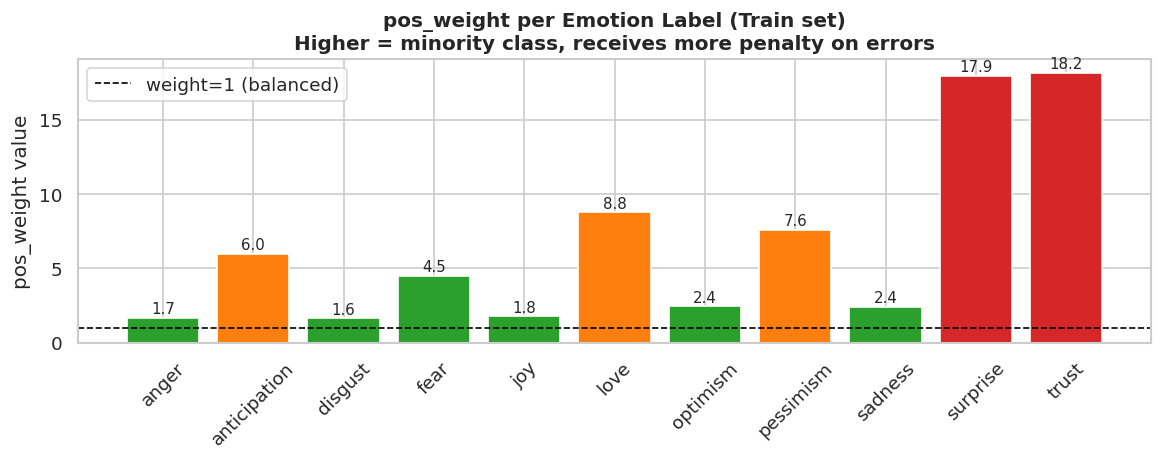

In [ ]:
# Visualize pos_weight
plt.figure(figsize=(10, 4))
colors = ['#d62728' if w > 10 else '#ff7f0e' if w > 5 else '#2ca02c'
          for w in pos_weight.values]
bars = plt.bar(pos_weight.index, pos_weight.values, color=colors, edgecolor='white')
plt.axhline(1.0, color='black', linestyle='--', lw=1, label='weight=1 (balanced)')
for bar, w in zip(bars, pos_weight.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{w:.1f}', ha='center', va='bottom', fontsize=9)
plt.title('pos_weight per Emotion Label (Train set)\n'
          'Higher = minority class, receives more penalty on errors',
          fontweight='bold')
plt.ylabel('pos_weight value')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('pos_weight.png', bbox_inches='tight')
plt.show()

## 6. Tweet Length After Cleaning

In [ ]:
# Verify lengths are still reasonable after cleaning
print('=== Word count after cleaning ===')
for df, name in [(train,'Train'), (dev,'Dev'), (test,'Test')]:
    wc = df['clean_tweet'].apply(lambda x: len(x.split()))
    print(f'{name}: mean={wc.mean():.1f}, median={wc.median():.0f}, '
          f'min={wc.min()}, max={wc.max()}')

# Check for very short tweets after cleaning (might be empty or near-empty)
very_short = (train['clean_tweet'].apply(lambda x: len(x.split())) <= 2).sum()
print(f'\nTrain tweets with ≤2 words after cleaning: {very_short} '
      f'({very_short/len(train)*100:.1f}%)')
if very_short > 0:
    print('Examples:')
    short_examples = train[
        train['clean_tweet'].apply(lambda x: len(x.split())) <= 2
    ][['Tweet','clean_tweet']].head(5)
    for _, row in short_examples.iterrows():
        print(f'  BEFORE: {row["Tweet"][:80]}')
        print(f'  AFTER : "{row["clean_tweet"]}"')

=== Word count after cleaning ===
Train: mean=16.2, median=17, min=1, max=84
Dev: mean=16.6, median=16, min=1, max=50
Test: mean=16.6, median=17, min=1, max=76

Train tweets with ≤2 words after cleaning: 71 (1.0%)
Examples:
  BEFORE: @TeamGrout glee
  AFTER : "glee"
  BEFORE: @downeysduckling nick fury
  AFTER : "nick fury"
  BEFORE: @simmy_hanley @Schrise also a 
  AFTER : "also a"
  BEFORE: Feeling #gloomy
  AFTER : "feeling gloomy"
  BEFORE: @ImJim_YoureNot  cyber bully
  AFTER : "cyber bully"


## 7. Extract Labels as NumPy Arrays

In [ ]:
# Extract clean texts and label matrices — ready for model input

X_train = train['clean_tweet'].tolist()
X_dev   = dev['clean_tweet'].tolist()
X_test  = test['clean_tweet'].tolist()

y_train = train[EMOTIONS].values.astype(np.float32)  # shape: (N, 11)
y_dev   = dev[EMOTIONS].values.astype(np.float32)
y_test  = test[EMOTIONS].values.astype(np.float32)

print('=== Final preprocessed shapes ===')
print(f'X_train: {len(X_train):,} texts | y_train: {y_train.shape}')
print(f'X_dev  : {len(X_dev):,} texts | y_dev  : {y_dev.shape}')
print(f'X_test : {len(X_test):,} texts | y_test : {y_test.shape}')
print(f'\nLabel dtype: {y_train.dtype} (float32 for BCE loss)')
print(f'\nSample cleaned tweet:')
print(f'  Text  : "{X_train[0]}"')
print(f'  Labels: {y_train[0]} → {[EMOTIONS[i] for i, v in enumerate(y_train[0]) if v==1]}')

=== Final preprocessed shapes ===
X_train: 6,838 texts | y_train: (6838, 11)
X_dev  : 886 texts | y_dev  : (886, 11)
X_test : 3,259 texts | y_test : (3259, 11)

Label dtype: float32 (float32 for BCE loss)

Sample cleaned tweet:
  Text  : "worry is a down payment on a problem you may never have' joyce meyer motivation leadership worry"
  Labels: [0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1.] → ['anticipation', 'optimism', 'trust']


## 8. Save Preprocessed Data

In [ ]:
# Save cleaned dataframes as TSV — reuse in all subsequent model notebooks
train[['ID', 'clean_tweet'] + EMOTIONS].to_csv('train_clean.tsv', sep='\t', index=False)
dev[['ID', 'clean_tweet'] + EMOTIONS].to_csv('dev_clean.tsv',   sep='\t', index=False)
test[['ID', 'clean_tweet'] + EMOTIONS].to_csv('test_clean.tsv',  sep='\t', index=False)

# Save pos_weight for reuse
import json
with open('pos_weight.json', 'w') as f:
    json.dump({e: round(float(w), 4) for e, w in pos_weight.items()}, f, indent=2)

print('Saved:')
print('  train_clean.tsv')
print('  dev_clean.tsv')
print('  test_clean.tsv')
print('  pos_weight.json')

Saved:
  train_clean.tsv
  dev_clean.tsv
  test_clean.tsv
  pos_weight.json
